# Exploratory Data Analysis

## Credit Risk Probability Model for Alternative Data

This notebook contains exploratory analysis of the Xente transaction dataset. The objective is to understand data characteristics, identify data quality issues, discover patterns, and generate hypotheses for feature engineering and credit risk modeling.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [7]:
print("Shape:", df.shape)

Shape: (95662, 16)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [9]:
df.sample(5)

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
51148,TransactionId_81424,BatchId_45066,AccountId_2478,SubscriptionId_655,CustomerId_2894,UGX,256,ProviderId_5,ProductId_4,airtime,ChannelId_3,7000.0,7000,2019-01-05T09:11:07Z,4,0
26512,TransactionId_24306,BatchId_85871,AccountId_3007,SubscriptionId_4678,CustomerId_3432,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,1000.0,1000,2018-12-14T10:47:33Z,2,0
54648,TransactionId_68541,BatchId_138205,AccountId_4249,SubscriptionId_4429,CustomerId_7343,UGX,256,ProviderId_4,ProductId_10,airtime,ChannelId_2,-10000.0,10000,2019-01-08T12:11:36Z,4,0
10534,TransactionId_13716,BatchId_4754,AccountId_2783,SubscriptionId_3524,CustomerId_3204,UGX,256,ProviderId_6,ProductId_4,airtime,ChannelId_3,1000.0,1000,2018-11-29T08:53:25Z,2,0
13266,TransactionId_121040,BatchId_56647,AccountId_1608,SubscriptionId_2553,CustomerId_1987,UGX,256,ProviderId_1,ProductId_15,financial_services,ChannelId_3,30000.0,30000,2018-12-02T08:02:43Z,2,0


## Dataset Overview

The dataset contains 95,662 transaction records and 16 features. No missing values were detected during the initial inspection. The dataset contains a mixture of identifiers, categorical variables, numerical variables, and timestamp information.

In [10]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [11]:
df.describe(include='object')

C:\Users\Pomi\AppData\Local\Temp\ipykernel_27888\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


In [12]:
numerical_cols = [
    "Amount",
    "Value",
    "PricingStrategy",
    "FraudResult"
]

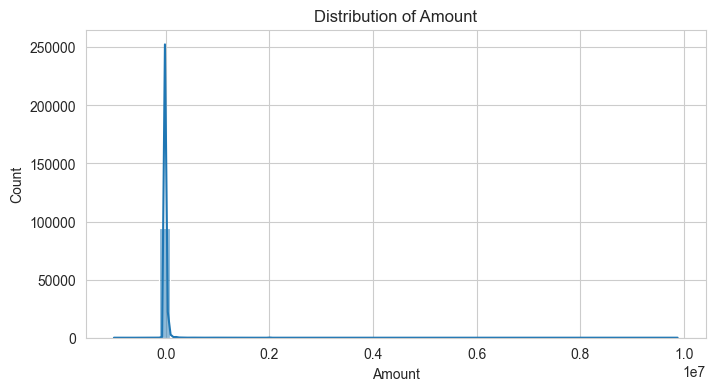

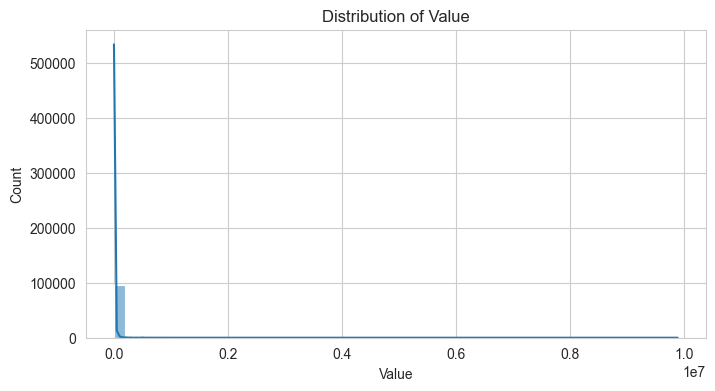

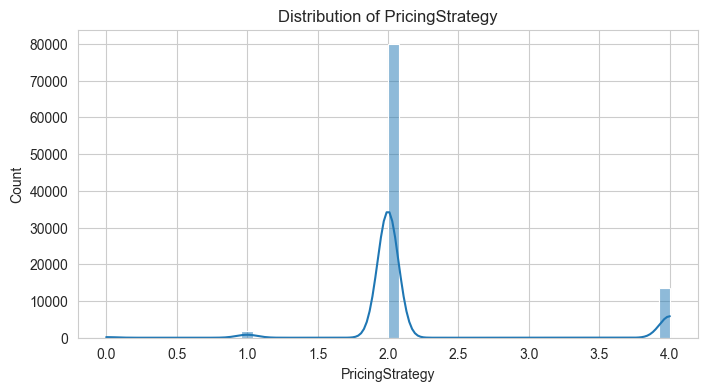

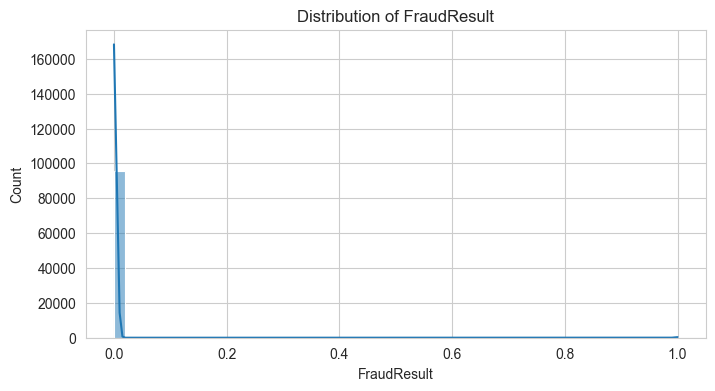

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

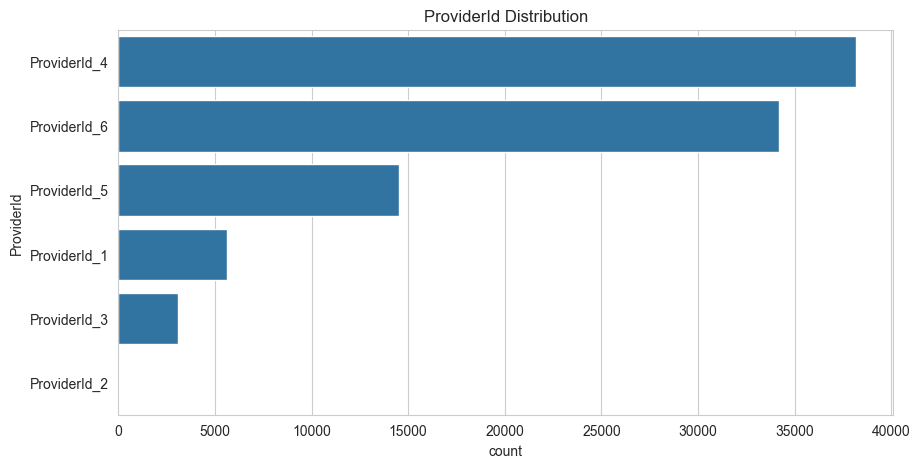

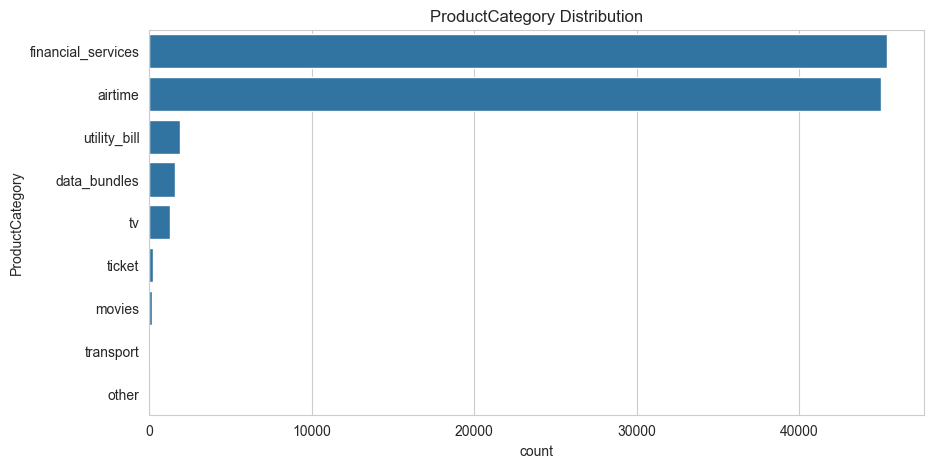

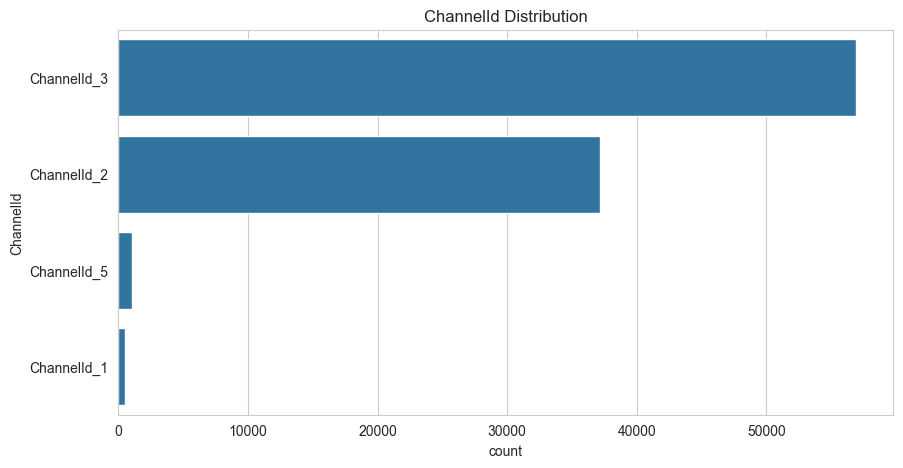

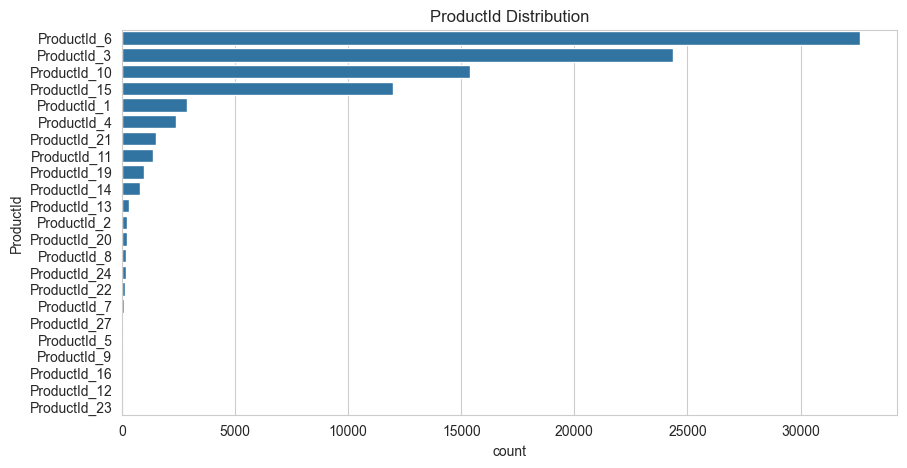

In [14]:
categorical_cols = [
    "ProviderId",
    "ProductCategory",
    "ChannelId",
    "ProductId"
]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index
    )
    plt.title(f"{col} Distribution")
    plt.show()

In [15]:
df["ProviderId"].value_counts()

ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

In [16]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

In [17]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

### Correlation Analysis

Correlation analysis was performed on numerical variables to identify relationships between features and detect possible redundancy.

Strong correlations may indicate overlapping information, while weak correlations suggest features capture different aspects of customer behavior.


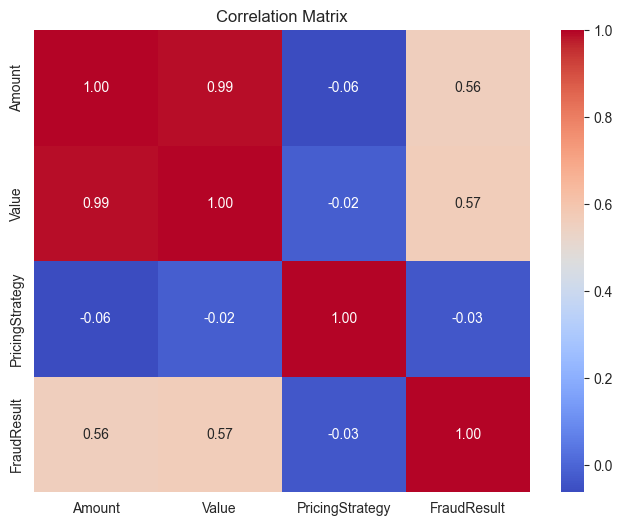

In [18]:
corr_cols = [
    "Amount",
    "Value",
    "PricingStrategy",
    "FraudResult"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

In [19]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


### Outlier Detection

Boxplots were used to identify extreme observations in numerical variables.

Outliers are particularly important in financial transaction datasets because unusually large transactions can significantly influence model behavior and summary statistics.


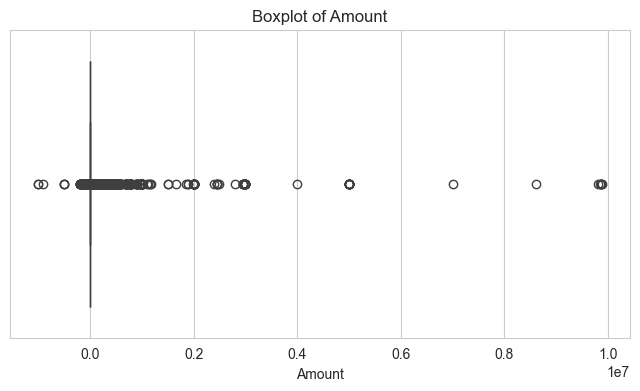

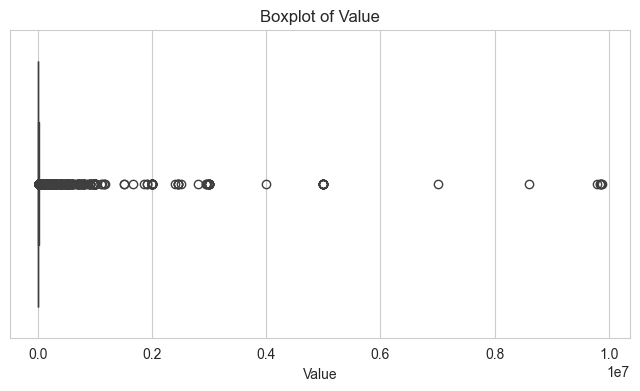

In [20]:
numerical_cols = [
    "Amount",
    "Value"
]

for col in numerical_cols:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

### Transaction Time Analysis

Transaction timestamps were converted into datetime format to understand the temporal characteristics of the dataset.

Temporal patterns may later support feature engineering through variables such as transaction hour, day, month, and year.


In [21]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

print(
    df["TransactionStartTime"].min()
)

print(
    df["TransactionStartTime"].max()
)

2018-11-15 02:18:49+00:00
2019-02-13 10:01:28+00:00


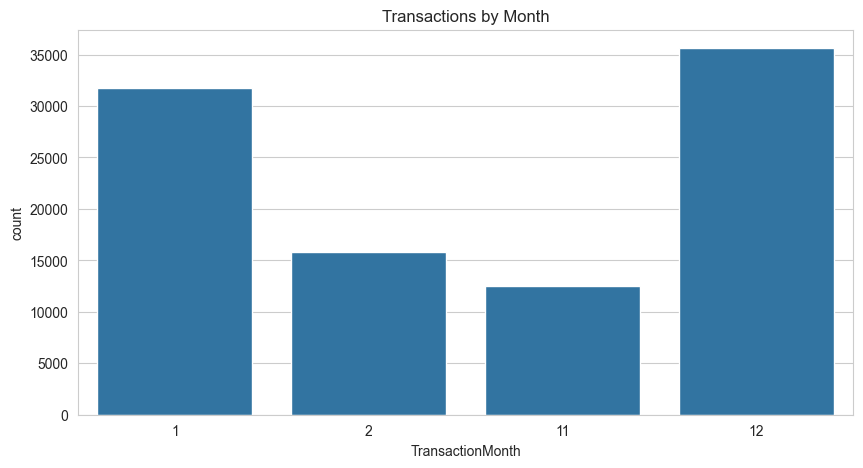

In [22]:
df["TransactionMonth"] = (
    df["TransactionStartTime"]
    .dt.month
)

plt.figure(figsize=(10,5))

sns.countplot(
    x="TransactionMonth",
    data=df
)

plt.title(
    "Transactions by Month"
)

plt.show()

In [23]:
df.columns.tolist()

['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'CountryCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'Amount',
 'Value',
 'TransactionStartTime',
 'PricingStrategy',
 'FraudResult',
 'TransactionMonth']

# Key Findings and Insights

## Insight 1: The Dataset Contains No Explicit Missing Values

Initial data quality assessment showed that all 16 features contain complete records with no missing values. This reduces the need for extensive imputation during preprocessing and simplifies the feature engineering pipeline. However, data quality checks should still be performed later to identify potential placeholder or invalid values.

---

## Insight 2: Transaction Values Are Highly Skewed and Contain Significant Outliers

Both the Amount and Value features exhibit strong skewness with a small number of extremely large transactions compared to the majority of observations. Boxplot analysis revealed substantial outliers, which is expected in financial transaction datasets. Appropriate scaling and transformation techniques should therefore be considered during feature engineering and model training.

---

## Insight 3: Customer Activity Appears Highly Uneven

The dataset contains 95,662 transactions generated by only 3,742 customers. Some customers appear thousands of times, indicating substantial differences in customer engagement and transaction frequency. This suggests that customer-level behavioral metrics such as transaction count, total spending, average transaction value, and recency are likely to be highly informative features for credit risk modeling.

---

## Insight 4: Platform Usage Is Concentrated in a Small Number of Categories

The majority of transactions belong to the financial_services and airtime categories, while several categories contribute only a very small number of observations. Similarly, a small number of providers and channels dominate transaction activity. This concentration indicates that customer behavior is not evenly distributed across the platform and that transaction category information may provide useful predictive signals.

---

## Insight 5: Transaction Timing May Contain Predictive Information

Transaction activity is unevenly distributed across months, with noticeably higher transaction volumes occurring during specific periods of the year. This suggests that temporal features derived from transaction timestamps, such as month, day, and hour, may help capture behavioral patterns relevant to customer segmentation and risk assessment.


# Implications for Feature Engineering

Based on the exploratory analysis, the following feature engineering opportunities were identified:

* Create customer-level aggregate features such as transaction count, total transaction amount, average transaction amount, and transaction variability.
* Extract temporal features from TransactionStartTime including hour, day, month, and year.
* Encode categorical variables such as ProductCategory, ChannelId, ProviderId, and ProductId.
* Consider scaling numerical variables due to the presence of significant outliers and skewed distributions.
* Construct Recency, Frequency, and Monetary (RFM) metrics for customer segmentation and proxy target generation in subsequent tasks.


In [24]:
import sys
import os

# Adds the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_processing import create_aggregate_features

agg_df = create_aggregate_features(df)

agg_df.head()

,CustomerId,TotalTransactionAmount,AverageTransactionAmount,TransactionCount,StdTransactionAmount
0,CustomerId_1,-10000.0,-10000.000000,1,NaN
1,CustomerId_10,-10000.0,-10000.000000,1,NaN
2,CustomerId_1001,20000.0,4000.000000,5,6558.963333
3,CustomerId_1002,4225.0,384.090909,11,560.498966
4,CustomerId_1003,20000.0,3333.333333,6,6030.478146


In [25]:
agg_df.shape

(3742, 5)

In [26]:
from src.data_processing import extract_datetime_features

time_df = extract_datetime_features(df)

time_df[
    [
        "TransactionHour",
        "TransactionDay",
        "TransactionMonth",
        "TransactionYear"
    ]
].head()

,TransactionHour,TransactionDay,TransactionMonth,TransactionYear
0,2,15,11,2018
1,2,15,11,2018
2,2,15,11,2018
3,3,15,11,2018
4,3,15,11,2018


## Aggregate Feature Engineering

Customer-level aggregate features were created to summarize transaction behavior. These features include total transaction amount, average transaction amount, transaction count, and transaction amount variability.

Such features provide a more informative representation of customer financial behavior than individual transaction records.

---

## Datetime Feature Extraction

Transaction timestamps were decomposed into hour, day, month, and year components.

These temporal variables may capture behavioral patterns associated with customer activity and transaction timing.

In [27]:
from src.data_processing import drop_unused_columns

clean_df = drop_unused_columns(df)

clean_df.columns

Index(['CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult',
       'TransactionMonth'],
      dtype='str')

## Removing Non-Predictive Identifiers

Several columns serve only as unique identifiers and do not contain meaningful behavioral information. These features were removed to reduce dimensionality and prevent the model from learning patterns based on arbitrary identifiers.

In [28]:
from src.data_processing import (
    prepare_data,
    build_pipeline
)

processed_df = prepare_data(df)

pipeline = build_pipeline()

X = pipeline.fit_transform(
    processed_df
)

print(X.shape)

(95662, 51)
